# VTX Data Exploration

Initial exploration of IMU data from VTX files.

**File**: Cornering Clockwise 1.vtx - 4 right-hand corners around a block

**Goals**:
1. Load and inspect the data
2. Visualize raw sensor readings
3. Identify which axes correspond to forward/lateral/vertical
4. Check data quality

**Important Notes**:
- The recording app applies a **zeroing function** - gravity has been removed
- All values are measured relative to the calibrated origin (zero reference)
- Vertical axis (Z) expected to be noisiest due to road vibrations
- This is test data from v1 hardware - validating the analysis pipeline

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add scripts to path
sys.path.insert(0, os.path.join(os.getcwd(), '../scripts'))

from load_vtx import load_vtx_file

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Load Data

In [2]:
# Load the VTX file
data = load_vtx_file('../data/sample-recordings/cornering_clockwise_1.vtx')

header = data['header']
metadata = data['metadata']
df = data['samples']

print("=== FILE INFO ===")
print(f"Version: {header['version'][0]}.{header['version'][1]}")
print(f"Sample count: {header['sample_count']:,}")
print(f"Header sample rate: {header['sample_rate']:.1f} Hz")
print(f"Computed sample rate: {header['computed_sample_rate']:.1f} Hz")
print(f"Duration: {header['duration']:.2f} seconds")
print(f"\nColumns: {list(df.columns)}")
print(f"\n=== METADATA ===")
print(f"Device: {metadata.get('device', {}).get('name', 'Unknown')}")
print(f"Session: {metadata.get('session', {}).get('createdAt', 'Unknown')}")

=== FILE INFO ===
Version: 1.0
Sample count: 3,093
Header sample rate: 10.0 Hz
Computed sample rate: 48.8 Hz
Duration: 63.34 seconds

Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'time_sec']

=== METADATA ===
Device: Vertex-IMU
Session: 2025-11-02T23:45:05.032Z


In [3]:
# Show first few rows
df.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,time_sec
0,1762127105173,-0.168,1.724,-0.034000,-0.7375,0.0375,-0.2625,0.6250,-7.2125,3.900,0.00
1,1762127105193,-0.118,1.754,-0.063999,-0.6750,-0.0875,-0.2000,0.6250,-7.2125,3.900,0.02
2,1762127105213,-0.168,1.784,-0.034000,-0.6750,0.0375,-0.3250,0.6250,-7.2125,3.900,0.04
3,1762127105233,-0.178,1.734,0.006000,-0.6125,0.1000,-0.0125,1.3125,-8.6500,2.775,0.06
4,1762127105253,-0.178,1.714,-0.034000,-0.7375,-0.0250,-0.3250,1.3125,-8.6500,2.775,0.08
5,1762127105273,-0.188,1.664,-0.004000,-0.6750,0.1625,-0.5125,-0.3750,-8.2125,4.275,0.10
6,1762127105293,-0.198,1.644,-0.034000,-0.5500,0.0375,-0.3875,-0.3750,-8.2125,4.275,0.12
7,1762127105313,-0.208,1.654,-0.014000,-0.4250,0.0375,-0.5125,-0.3750,-8.2125,4.275,0.14
8,1762127105333,-0.208,1.714,-0.044000,0.0750,-0.0250,-0.3875,0.3125,-7.9000,3.900,0.16
9,1762127105353,-0.208,1.774,-0.034000,-0.0500,-0.0875,-0.2625,0.3125,-7.9000,3.900,0.18


## 2. Basic Statistics

Calculate mean and standard deviation for each axis to identify patterns.

In [4]:
# Accelerometer statistics
print("=== ACCELEROMETER (m/s²) ===")
accel_cols = ['accel_x', 'accel_y', 'accel_z']
accel_stats = df[accel_cols].describe()
print(accel_stats)

print("\n=== GYROSCOPE (rad/s) ===")
gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']
gyro_stats = df[gyro_cols].describe()
print(gyro_stats)

if 'mag_x' in df.columns:
    print("\n=== MAGNETOMETER (µT) ===")
    mag_cols = ['mag_x', 'mag_y', 'mag_z']
    mag_stats = df[mag_cols].describe()
    print(mag_stats)

=== ACCELEROMETER (m/s²) ===
           accel_x      accel_y      accel_z
count  3093.000000  3093.000000  3093.000000
mean     -0.062507     1.145853     0.064157
std       3.771142     1.222729     3.957267
min     -27.308001    -4.946000   -26.733999
25%      -1.798000     0.424000    -1.434000
50%      -0.178000     1.124000    -0.044000
75%       1.532000     1.794000     1.516001
max      36.612000     8.124000    29.986002

=== GYROSCOPE (rad/s) ===
            gyro_x       gyro_y       gyro_z
count  3093.000000  3093.000000  3093.000000
mean     -0.391578     1.302433    -4.065382
std       6.876321     7.086267    11.368521
min     -33.862499   -43.962502   -58.700001
25%      -2.925000    -1.775000    -8.512500
50%       0.075000     0.350000    -1.325000
75%       2.950000     3.475000     2.300000
max      28.637501    75.412498    25.674999

=== MAGNETOMETER (µT) ===
             mag_x        mag_y        mag_z
count  3093.000000  3093.000000  3093.000000
mean     22.43614

## 3. Identify Axes

**Note**: The recording app applies a zeroing function, so gravity has been removed from the data.
All values are measured relative to the calibrated origin.

Use statistical analysis to identify which axis corresponds to:
- **Vertical (Z)**: Likely noisiest due to road vibrations and bumps
- **Forward**: Should have second highest variance (acceleration/braking)
- **Lateral**: Smoothest, only changes during corners

In [5]:
# Calculate metrics for axis identification
# With zeroing applied, we look at noise characteristics instead of gravity

axes_analysis = []
for axis in ['x', 'y', 'z']:
    col = f'accel_{axis}'
    mean_val = df[col].mean()
    variance = df[col].var()
    std_val = df[col].std()
    
    # Calculate high-frequency noise (difference between consecutive samples)
    noise = df[col].diff().abs().mean()
    
    axes_analysis.append({
        'axis': axis,
        'mean': mean_val,
        'variance': variance,
        'std': std_val,
        'noise': noise  # Higher = more high-frequency content (vibrations)
    })

axes_df = pd.DataFrame(axes_analysis)
print("=== AXIS ANALYSIS ===")
print(axes_df)

# Identify axes
# Vertical: Highest noise (road vibrations)
vertical_axis = axes_df.loc[axes_df['noise'].idxmax(), 'axis']
remaining = axes_df[axes_df['axis'] != vertical_axis]

# Forward: Higher variance of the remaining (acceleration/braking)
forward_axis = remaining.loc[remaining['variance'].idxmax(), 'axis']

# Lateral: Remaining axis
lateral_axis = remaining[remaining['axis'] != forward_axis].iloc[0]['axis']

print(f"\n=== IDENTIFIED AXES (Zero-Referenced Data) ===")
print(f"Vertical (Z): {vertical_axis.upper()} (noise: {axes_df[axes_df['axis']==vertical_axis]['noise'].iloc[0]:.3f}, variance: {axes_df[axes_df['axis']==vertical_axis]['variance'].iloc[0]:.3f})")
print(f"Forward: {forward_axis.upper()} (variance: {axes_df[axes_df['axis']==forward_axis]['variance'].iloc[0]:.3f})")
print(f"Lateral: {lateral_axis.upper()} (variance: {axes_df[axes_df['axis']==lateral_axis]['variance'].iloc[0]:.3f})")
print(f"\nNote: Data is zero-referenced (gravity removed during calibration)")

=== AXIS ANALYSIS ===
  axis      mean   variance       std     noise
0    x -0.062507  14.221511  3.771142  3.327170
1    y  1.145853   1.495066  1.222729  1.014563
2    z  0.064157  15.659962  3.957267  3.757917

=== IDENTIFIED AXES (Zero-Referenced Data) ===
Vertical (Z): Z (noise: 3.758, variance: 15.660)
Forward: X (variance: 14.222)
Lateral: Y (variance: 1.495)

Note: Data is zero-referenced (gravity removed during calibration)


## 4. Visualize Raw Data

Plot all axes over time to see patterns.

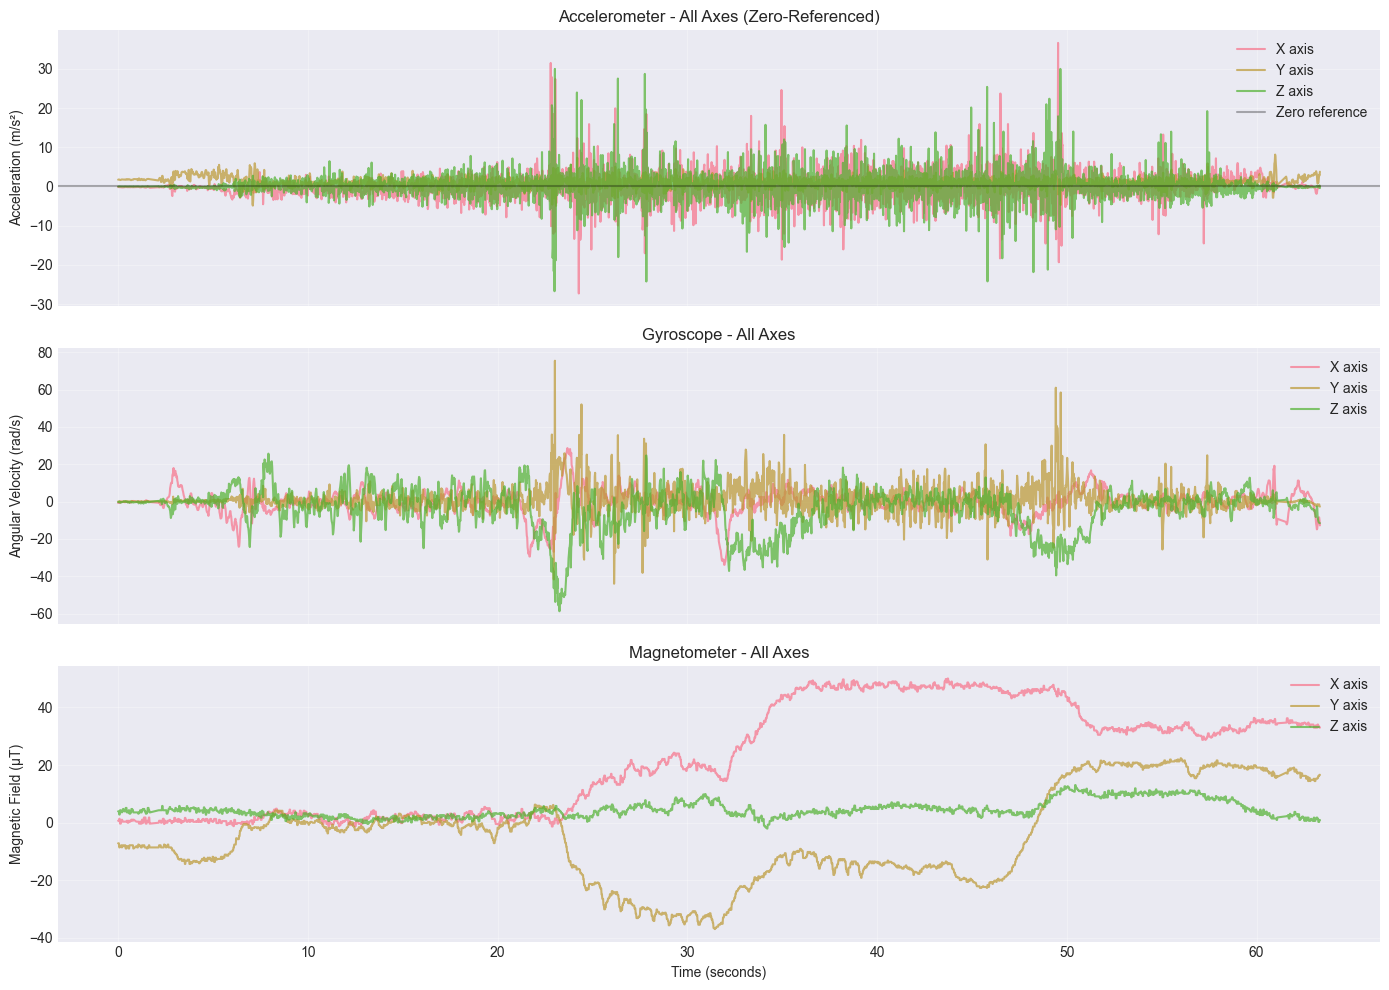

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Accelerometer (zero-referenced, no gravity expected)
for axis in ['x', 'y', 'z']:
    axes[0].plot(df['time_sec'], df[f'accel_{axis}'], label=f'{axis.upper()} axis', alpha=0.7)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, label='Zero reference')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Accelerometer - All Axes (Zero-Referenced)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Gyroscope
for axis in ['x', 'y', 'z']:
    axes[1].plot(df['time_sec'], df[f'gyro_{axis}'], label=f'{axis.upper()} axis', alpha=0.7)
axes[1].set_ylabel('Angular Velocity (rad/s)')
axes[1].set_title('Gyroscope - All Axes')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Magnetometer (if available)
if 'mag_x' in df.columns:
    for axis in ['x', 'y', 'z']:
        axes[2].plot(df['time_sec'], df[f'mag_{axis}'], label=f'{axis.upper()} axis', alpha=0.7)
    axes[2].set_ylabel('Magnetic Field (µT)')
    axes[2].set_title('Magnetometer - All Axes')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No magnetometer data', ha='center', va='center')
    axes[2].set_title('Magnetometer - Not Available')

axes[2].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

## 5. Apply Smoothing and Look for Corners

The raw lateral acceleration is noisy. Let's apply different smoothing techniques to see the corner patterns more clearly.

We'll test:
1. **Simple Moving Average** - Basic smoothing
2. **Exponential Moving Average** - Better for real-time
3. **Butterworth Low-Pass Filter** - Recommended approach

In [ ]:
# Implement smoothing functions
from scipy import signal

def simple_moving_average(data, window_size=10):
    """Apply simple moving average filter"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

def exponential_moving_average(data, alpha=0.1):
    """Apply exponential moving average filter"""
    result = np.zeros_like(data)
    result[0] = data[0]
    for i in range(1, len(data)):
        result[i] = alpha * data[i] + (1 - alpha) * result[i-1]
    return result

def butterworth_lowpass(data, cutoff=5.0, sample_rate=None, order=4):
    """
    Apply Butterworth low-pass filter
    
    Args:
        data: Input signal
        cutoff: Cutoff frequency in Hz (remove noise above this)
        sample_rate: Sample rate in Hz
        order: Filter order (higher = sharper cutoff)
    """
    if sample_rate is None:
        raise ValueError("Sample rate must be provided")
    
    nyquist = sample_rate / 2
    normal_cutoff = cutoff / nyquist
    
    if normal_cutoff >= 1.0:
        raise ValueError(f"Cutoff frequency ({cutoff} Hz) must be less than Nyquist frequency ({nyquist} Hz)")
    
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

# Get lateral acceleration
lateral_col = f'accel_{lateral_axis}'
lateral_data = df[lateral_col].values
sample_rate = header['computed_sample_rate']

print(f"Using lateral axis: {lateral_axis.upper()}")
print(f"Sample rate: {sample_rate:.1f} Hz")

# Apply different smoothing techniques
lateral_sma = simple_moving_average(lateral_data, window_size=10)
lateral_ema = exponential_moving_average(lateral_data, alpha=0.1)
lateral_butterworth = butterworth_lowpass(lateral_data, cutoff=2.0, sample_rate=sample_rate, order=4)

# Plot comparison
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Raw data
axes[0].plot(df['time_sec'], lateral_data, label='Raw', linewidth=0.5, alpha=0.7, color='lightgray')
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[0].set_ylabel('Accel (m/s²)')
axes[0].set_title('Raw Lateral Acceleration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Simple Moving Average
axes[1].plot(df['time_sec'], lateral_data, label='Raw', linewidth=0.5, alpha=0.3, color='lightgray')
axes[1].plot(df['time_sec'], lateral_sma, label='SMA (window=10)', linewidth=1.5, color='blue')
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[1].set_ylabel('Accel (m/s²)')
axes[1].set_title('Simple Moving Average (Window=10 samples)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Exponential Moving Average
axes[2].plot(df['time_sec'], lateral_data, label='Raw', linewidth=0.5, alpha=0.3, color='lightgray')
axes[2].plot(df['time_sec'], lateral_ema, label='EMA (α=0.1)', linewidth=1.5, color='green')
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[2].set_ylabel('Accel (m/s²)')
axes[2].set_title('Exponential Moving Average (α=0.1)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Butterworth Low-Pass Filter (Recommended)
axes[3].plot(df['time_sec'], lateral_data, label='Raw', linewidth=0.5, alpha=0.3, color='lightgray')
axes[3].plot(df['time_sec'], lateral_butterworth, label='Butterworth (cutoff=2Hz)', linewidth=2, color='red')
axes[3].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[3].set_ylabel('Accel (m/s²)')
axes[3].set_title('Butterworth Low-Pass Filter (Recommended) - Cutoff=2Hz, Order=4')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

print(f"\nLateral acceleration stats (raw):")
print(f"  Mean: {lateral_data.mean():.3f} m/s²")
print(f"  Std: {lateral_data.std():.3f} m/s²")
print(f"  Range: [{lateral_data.min():.3f}, {lateral_data.max():.3f}] m/s²")

print(f"\nLateral acceleration stats (Butterworth filtered):")
print(f"  Mean: {lateral_butterworth.mean():.3f} m/s²")
print(f"  Std: {lateral_butterworth.std():.3f} m/s²")
print(f"  Range: [{lateral_butterworth.min():.3f}, {lateral_butterworth.max():.3f}] m/s²")
print(f"  Noise reduction: {(1 - lateral_butterworth.std()/lateral_data.std())*100:.1f}%")

## 5b. Detect Corners Using Filtered Data

Now that we have smooth data, let's detect the 4 corner events using peak detection.

In [ ]:
# Detect corners using filtered lateral acceleration
from scipy.signal import find_peaks

# Use absolute value to detect both left and right turns
lateral_abs = np.abs(lateral_butterworth)

# Find peaks (corners) - adjust threshold and distance based on data
threshold = lateral_abs.std() * 1.5  # 1.5x standard deviation
min_distance = int(sample_rate * 2)  # Minimum 2 seconds between corners

peaks, properties = find_peaks(
    lateral_abs,
    height=threshold,
    distance=min_distance,
    prominence=lateral_abs.std() * 0.5
)

print(f"=== CORNER DETECTION ===")
print(f"Threshold: {threshold:.3f} m/s²")
print(f"Min distance: {min_distance} samples (~{min_distance/sample_rate:.1f} seconds)")
print(f"Found {len(peaks)} potential corners")
print(f"Expected: 4 corners (4 right turns)")

# Plot detected corners
plt.figure(figsize=(14, 6))
plt.plot(df['time_sec'], lateral_butterworth, label='Filtered Lateral Accel', linewidth=1.5, color='blue', alpha=0.7)
plt.plot(df['time_sec'], lateral_abs, label='Absolute Value', linewidth=1, color='gray', alpha=0.5)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.5, label=f'Detection threshold ({threshold:.2f})')
plt.axhline(y=-threshold, color='r', linestyle='--', alpha=0.5)

# Mark detected corners
for peak_idx in peaks:
    peak_time = df['time_sec'].iloc[peak_idx]
    peak_value = lateral_butterworth[peak_idx]
    plt.plot(peak_time, peak_value, 'ro', markersize=10, label='Detected corner' if peak_idx == peaks[0] else '')
    plt.annotate(f't={peak_time:.1f}s', 
                xy=(peak_time, peak_value),
                xytext=(10, 10), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel('Time (seconds)')
plt.ylabel('Lateral Acceleration (m/s²)')
plt.title(f'Corner Detection - Found {len(peaks)} corners (Expected: 4)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show details of detected corners
if len(peaks) > 0:
    print(f"\n=== DETECTED CORNERS ===")
    for i, peak_idx in enumerate(peaks):
        peak_time = df['time_sec'].iloc[peak_idx]
        peak_value = lateral_butterworth[peak_idx]
        direction = "RIGHT" if peak_value > 0 else "LEFT"
        print(f"Corner {i+1}: t={peak_time:.2f}s, accel={peak_value:.3f} m/s² ({direction} turn)")
        
    # Check spacing between corners
    if len(peaks) > 1:
        print(f"\n=== CORNER SPACING ===")
        for i in range(len(peaks)-1):
            time_diff = df['time_sec'].iloc[peaks[i+1]] - df['time_sec'].iloc[peaks[i]]
            print(f"Corner {i+1} to {i+2}: {time_diff:.2f} seconds")
else:
    print("\n⚠ No corners detected. Try adjusting threshold or filter parameters.")

## Summary

This notebook provides initial exploration of VTX IMU data:
1. Loaded and inspected file metadata
2. Identified axes based on statistical analysis (noise characteristics, not gravity)
3. Visualized raw sensor data
4. Checked data quality

**Key Findings**:
- Data is **zero-referenced** (gravity removed by calibration)
- Axis identification uses **noise analysis** instead of gravity
- Vertical axis identified by highest high-frequency noise (road vibrations)

**Next Steps**:
- Apply filtering to reduce noise
- Calculate derived metrics (lean angle from gyro integration)
- Detect corner events using lateral acceleration and gyroscope
- Test with v2 hardware data for better validation

**Note**: This analysis pipeline works with zero-referenced data. Lean angle calculations will rely on gyroscope integration rather than gravity vector rotation.